# Feature Engineering — Birleşik Master

EDA bulgularından **ML-ready** feature tabloları. Grafikler her adımın **hemen altında** inline gösterilir.

> Detaylı Gün 8 notebook: `GUN08_feature_engineering.ipynb`


In [1]:
# Kurulum
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'feature_engineering' and (ROOT / 'feature_engineering').exists():
    ROOT = ROOT / 'feature_engineering'
EDA = ROOT.parent / 'eda'
sys.path.insert(0, str(EDA))
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, DATA_DIR
from fe_utils.features import (
    build_features_30min, build_features_daily,
    build_manifold_features, merge_feature_layers, export_features,
)
from fe_utils.fe_plots import (
    setup_fe_style,
    plot_data_inventory,
    plot_feature_distributions, plot_null_rates, plot_signal_counts,
    plot_kk_oran_vs_satis, plot_gece_gunduz_box, plot_hourly_kk,
    plot_doluluk_vs_kayip, plot_daily_fark_alarm, plot_daily_fark_vs_satis,
    plot_daily_rollup, plot_manifold_correlations, plot_manifold_n_donem,
    plot_merged_overlay, plot_feature_corr_heatmap, plot_export_summary,
)

setup_fe_style()
%matplotlib inline
print('Veri:', DATA_DIR)

Veri: /Users/mangtay/Desktop/Staj/data


## 1 — Veri yükleme

In [2]:
dfs = load_all()
print({k: v.shape for k, v in dfs.items()})

{'stations': (8, 3), 'tanks': (32, 11), 'mapping': (81, 7), 'transactions': (231874, 11), 'deliveries': (1109, 12), 'inventory_30min': (138194, 11), 'ue1t_30min': (138194, 16), 'daily': (2880, 13)}


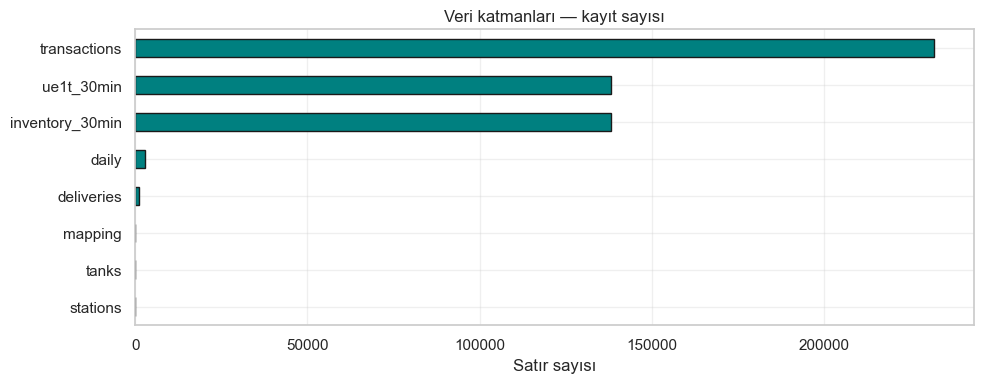

In [3]:
plot_data_inventory(dfs)

## 2 — 30 dk feature tablosu

In [4]:
feat_30 = build_features_30min(dfs)
print('Shape:', feat_30.shape)
display(feat_30.head())

Shape: (138194, 44)


,saat_1,saat_2,istasyon_kodu,tank_no,akaryakit_turu_x,sicaklik,donem_basi_stok,baslangic_seviyesi_cm,tanka_dolum,donem_sonu_stok,...,akaryakit_turu_y,is_manifold,manifold_grup_no,bolmeli,bolme_grup_no,doluluk_oran,sinyal_satisiz_kayip,sinyal_gece_dusus,sinyal_stok_dondu,sinyal_su_spike
0,2026-01-01 00:00:00,2026-01-01 00:30:00,IST_001,1,Motorin(Excellium),19.86,16846.98,142.8331,0.0,16721.87,...,Motorin(Excellium),1,1,0,0,0.727038,0,0,0,0
1,2026-01-01 00:30:00,2026-01-01 01:00:00,IST_001,1,Motorin(Excellium),19.66,16721.87,141.7724,0.0,16565.41,...,Motorin(Excellium),1,1,0,0,0.720235,0,0,0,0
2,2026-01-01 01:00:00,2026-01-01 01:30:00,IST_001,1,Motorin(Excellium),19.53,16565.41,140.4459,0.0,16548.00,...,Motorin(Excellium),1,1,0,0,0.719478,0,0,0,0
3,2026-01-01 01:30:00,2026-01-01 02:00:00,IST_001,1,Motorin(Excellium),19.39,16548.00,140.2983,0.0,16545.95,...,Motorin(Excellium),1,1,0,0,0.719389,0,0,0,0
4,2026-01-01 02:00:00,2026-01-01 02:30:00,IST_001,1,Motorin(Excellium),19.22,16545.95,140.2809,0.0,16543.33,...,Motorin(Excellium),1,1,0,0,0.719275,0,0,0,0


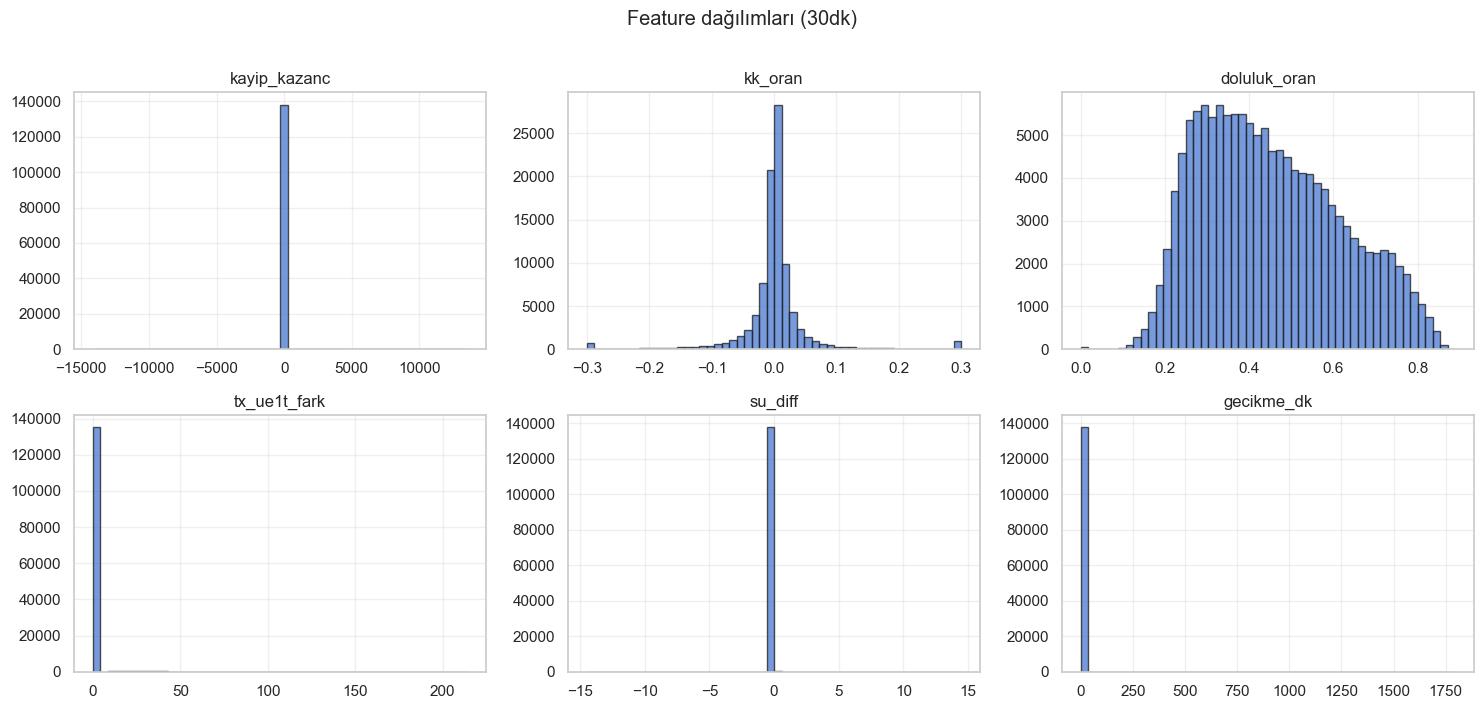

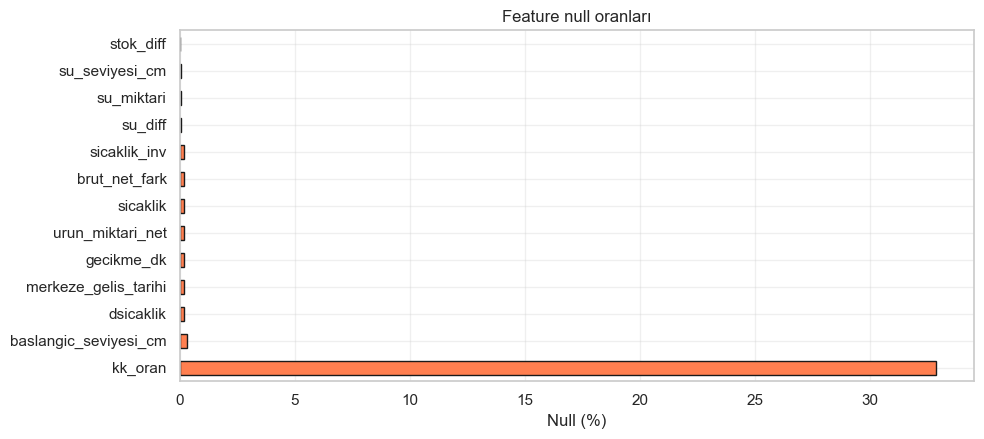

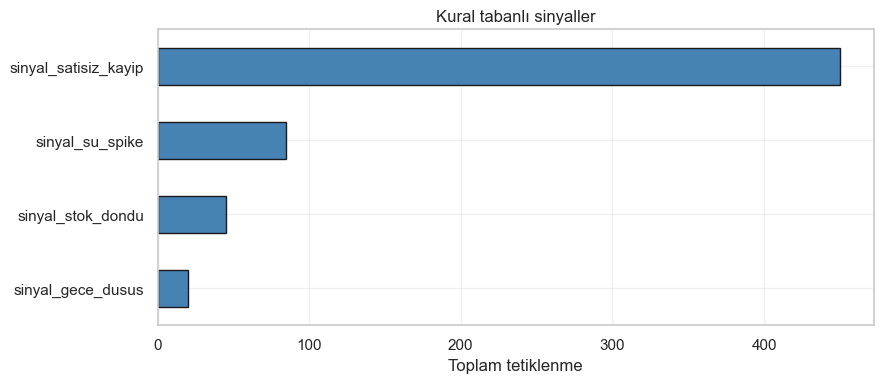

In [5]:
plot_feature_distributions(feat_30)
plot_null_rates(feat_30)
plot_signal_counts(feat_30)

### 2b — 30 dk davranış grafikleri

In [6]:
# Satış, saat ve doluluk ilişkileri

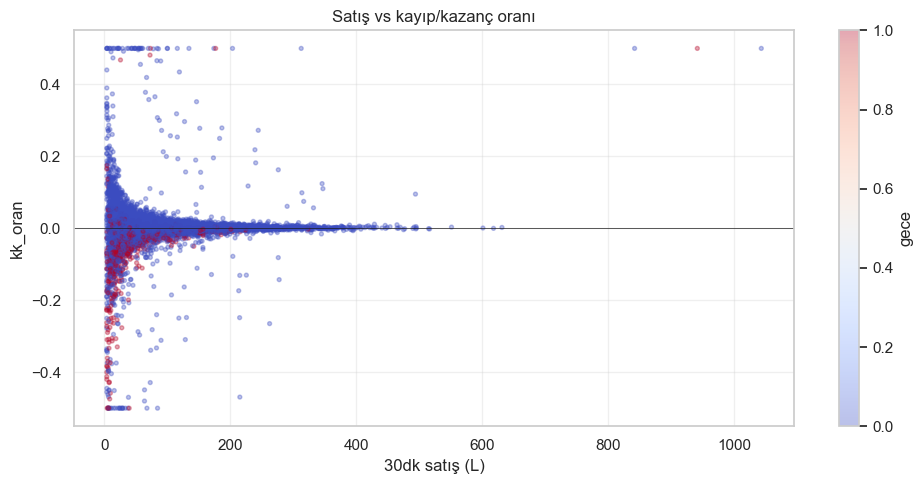

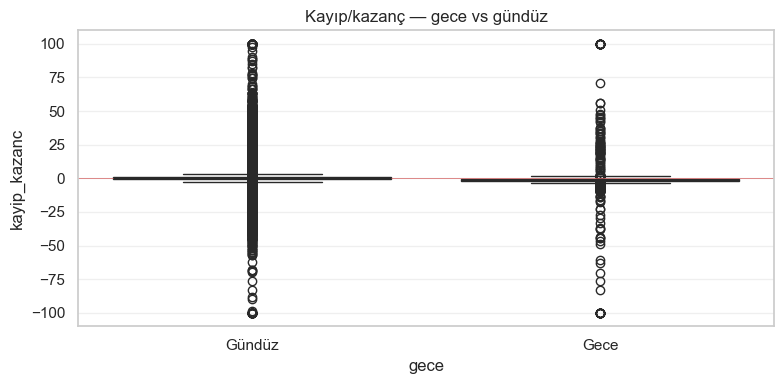

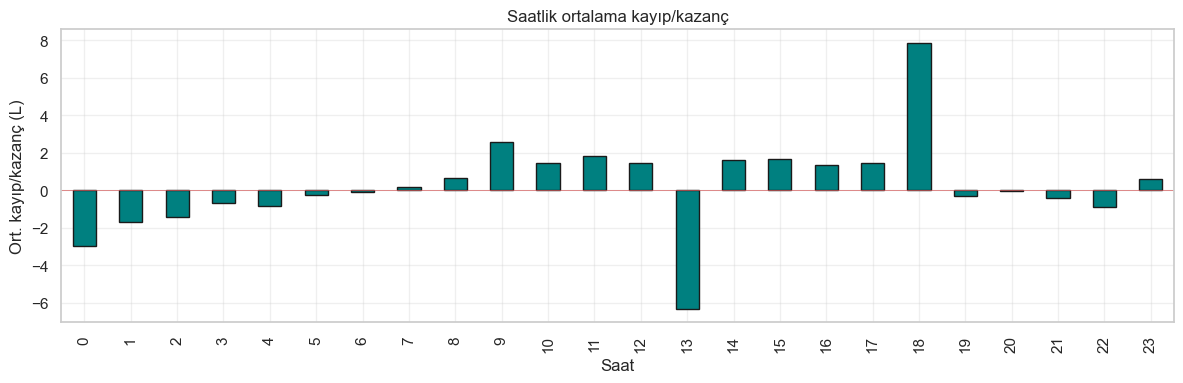

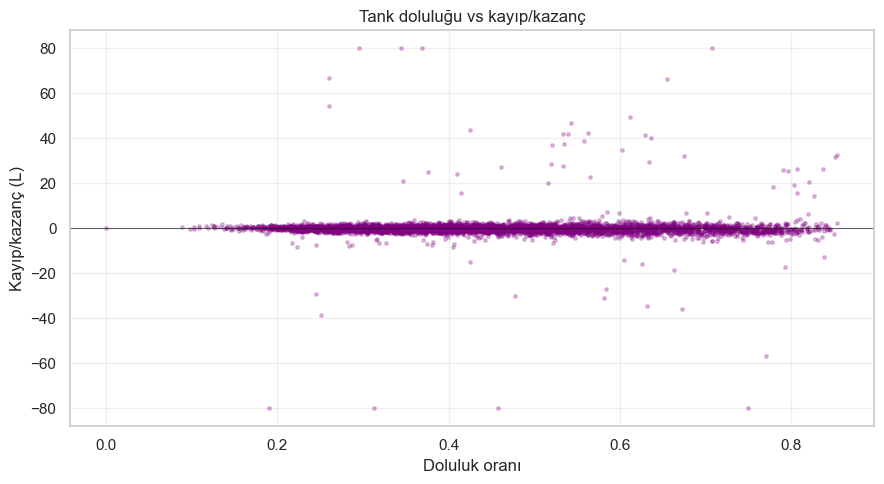

In [7]:
plot_kk_oran_vs_satis(feat_30)
plot_gece_gunduz_box(feat_30)
plot_hourly_kk(feat_30)
plot_doluluk_vs_kayip(feat_30)

## 3 — Günlük feature tablosu

In [8]:
feat_day = build_features_daily(dfs)
print('Shape:', feat_day.shape)
display(feat_day.describe().round(2).T.head(12))

Shape: (2880, 20)


,count,mean,min,25%,50%,75%,max,std
tarih,2880,2026-02-14 12:00:00,2026-01-01 00:00:00,2026-01-23 00:00:00,2026-02-14 12:00:00,2026-03-09 00:00:00,2026-03-31 00:00:00,NaN
tank_no,2880.0,2.59,1.0,1.75,2.5,3.25,5.0,1.27
acilis,2880.0,7725.89,1260.37,4932.59,7151.45,10238.92,20950.55,3795.99
kapanis,2880.0,7701.77,1260.37,4930.63,7147.26,10187.54,19042.16,3774.05
dolum,2880.0,2928.31,0.0,0.0,0.0,6027.15,17356.93,4111.4
azalma_miktari,2880.0,2952.43,-2962.43,1601.62,2910.89,4109.52,10829.81,1490.67
satis,2880.0,2966.31,10.74,1608.88,2896.8,4101.79,47893.2,1687.15
fark,2880.0,13.89,-4623.45,-8.23,-0.58,7.35,43121.62,849.34
oran,2880.0,0.02,-304.33,-0.32,-0.02,0.29,238.27,10.48
sel,2880.0,38.83,24.05,32.05,38.48,44.51,263.47,8.44


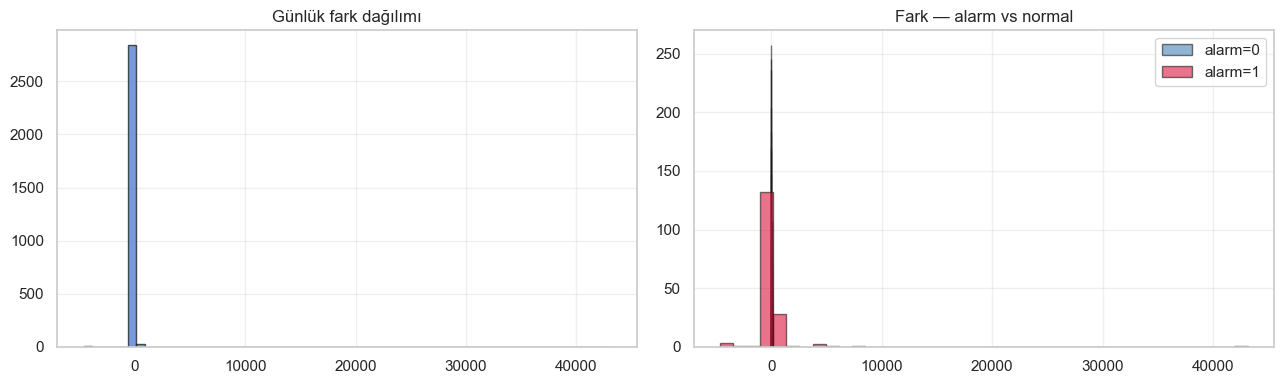

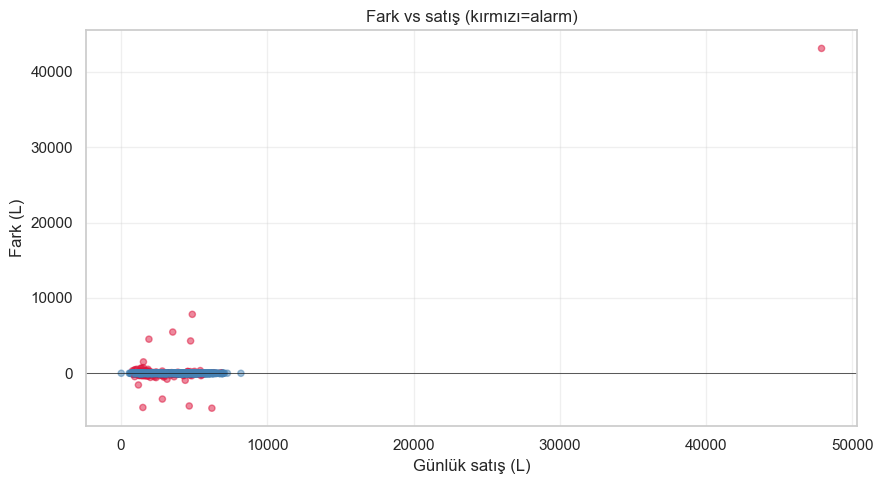

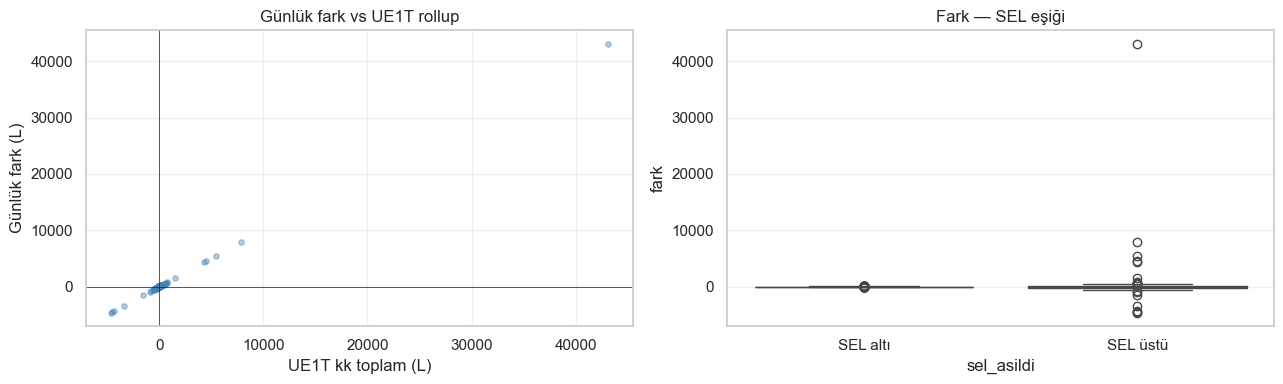

In [9]:
plot_daily_fark_alarm(feat_day)
plot_daily_fark_vs_satis(feat_day)
plot_daily_rollup(feat_day)

## 4 — Manifold metrikleri

In [10]:
feat_man = build_manifold_features(feat_30, dfs)
display(feat_man)

,istasyon_kodu,manifold_grup_no,tank_a,tank_b,kk_corr,n_donem
0,IST_001,1,1,3,-0.939354,4320
1,IST_004,1,2,4,-0.961084,4320
2,IST_005,1,1,3,-0.069178,4318
3,IST_007,1,2,4,-0.075254,4310


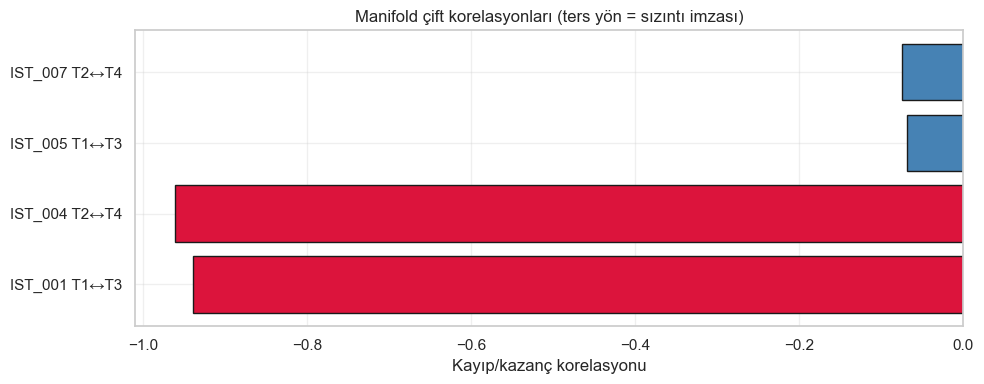

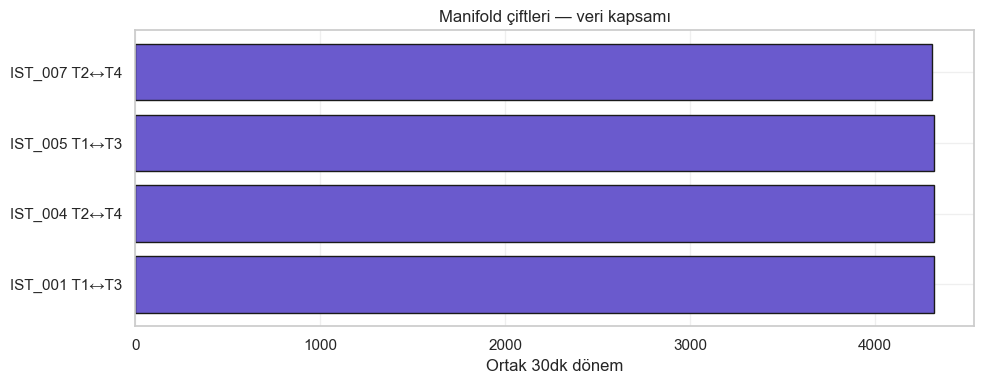

In [11]:
plot_manifold_correlations(feat_man)
plot_manifold_n_donem(feat_man)

## 5 — Birleştirme

In [12]:
feat_merged = merge_feature_layers(feat_30, feat_day)
print('Shape:', feat_merged.shape)

Shape: (138194, 52)


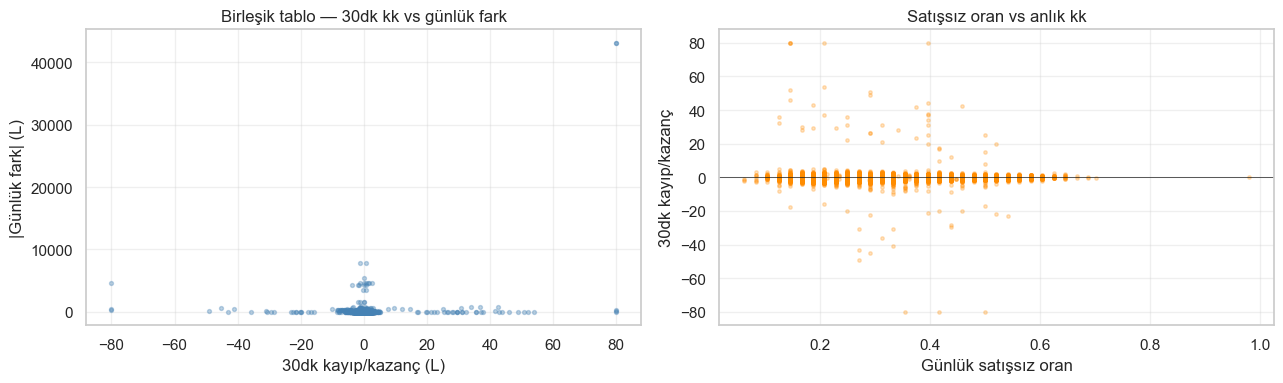

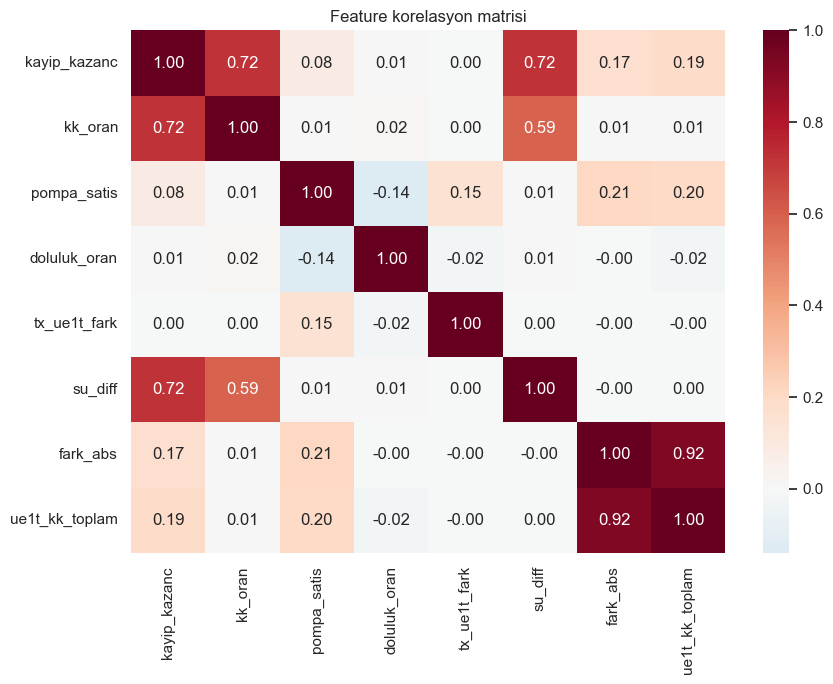

In [13]:
plot_merged_overlay(feat_merged)
plot_feature_corr_heatmap(feat_merged)

## 6 — Export (CSV)

In [14]:
paths = export_features(feat_30, feat_day, feat_man, feat_merged)
for n, p in paths.items(): print(n, '→', p.name)

features_30min → features_30min.csv
features_daily → features_daily.csv
features_manifold → features_manifold.csv
features_merged_30min → features_merged_30min.csv


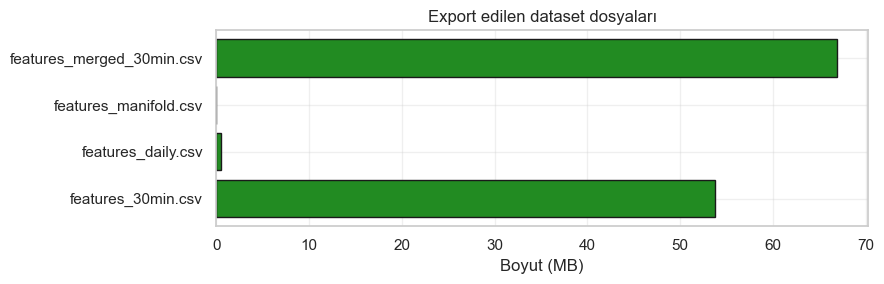

In [15]:
plot_export_summary(paths)